In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import bptt
from flightning.envs import HoveringStateEnv, rollout
from flightning.envs.wrappers import MinMaxObservationWrapper
from flightning.modules import MLP

%matplotlib inline

2025-11-21 13:21:15.210300: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Training a State-based Quadrotor Policy With BPTT

## Seed it

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## Setup the Training Environment

In [3]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringStateEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=0.2,
    pitch_roll_scale=0.2,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
)
env = MinMaxObservationWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

239


## Define the Policy Network

In [4]:
policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
policy_params = policy_net.initialize(key_init)

## Setup the Optimizer and Train State

In [5]:
from orbax.checkpoint import PyTreeCheckpointer
restore_chkpoint=False
if restore_chkpoint:
    ckptr = PyTreeCheckpointer()
    path = FLIGHTNING_PATH + "/../examples/saved_params"
    params_loaded = ckptr.restore(path)
    
    print("Loaded params")
    print(params_loaded['params']['Dense_0']['kernel'])  

In [6]:
N = 1000
scheduler = optax.cosine_decay_schedule(1e-2, N)
tx = optax.adam(scheduler)
if restore_chkpoint:
    print("Reloading params")
    train_state = TrainState.create(
    apply_fn=policy_net.apply, params=params_loaded, tx=tx
)
else:
    print("new params")
    train_state = TrainState.create(
        apply_fn=policy_net.apply, params=policy_params, tx=tx
    )

new params


## Initial Rollout

In [7]:
def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy(obs, key):
    return train_state.apply_fn(train_state.params, obs)

transitions = get_rollouts(env, policy, 10, jax.random.key(3))

/home/yanrui/tempstorage4/rpg_flightning/flightning/envs/hovering_state_env.py:440: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


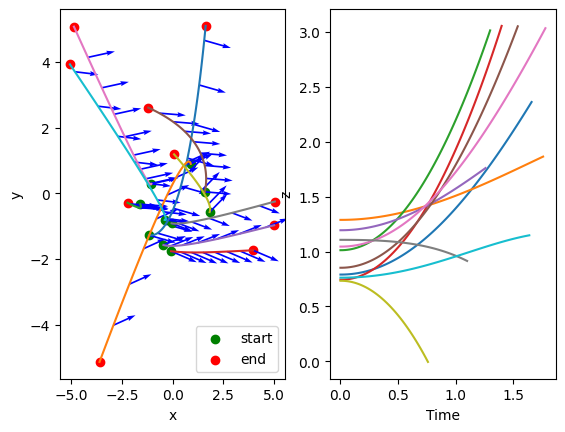

In [8]:
env.plot_trajectories(transitions)

## Train the Policy Using BPTT

In [9]:
time_start = time.time()
res_dict = bptt.train(
    env,
    train_state,
    num_epochs=1000,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=200,
    key=key_bptt,
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

Episode: 0, Grad max: 20.8216
Episode: 0, Loss: 105.39
Episode: 10, Grad max: 15.0014
Episode: 10, Loss: 110.26
Episode: 20, Grad max: 2.7305
Episode: 20, Loss: 26.03
Episode: 30, Grad max: 3.1782
Episode: 30, Loss: 19.29
Episode: 40, Grad max: 20.0018
Episode: 40, Loss: 14.95
Episode: 50, Grad max: 23.7240
Episode: 50, Loss: 15.47
Episode: 60, Grad max: 12.8677
Episode: 60, Loss: 11.93
Episode: 70, Grad max: 0.7923
Episode: 70, Loss: 10.58
Episode: 80, Grad max: 2.5025
Episode: 80, Loss: 10.57
Episode: 90, Grad max: 0.5750
Episode: 90, Loss: 9.36
Episode: 100, Grad max: 1.1822
Episode: 100, Loss: 9.66
Episode: 110, Grad max: 1.2200
Episode: 110, Loss: 9.22
Episode: 120, Grad max: 1.0323
Episode: 120, Loss: 8.67
Episode: 130, Grad max: 1.5391
Episode: 130, Loss: 8.72
Episode: 140, Grad max: 0.4596
Episode: 140, Loss: 8.65
Episode: 150, Grad max: 1.4078
Episode: 150, Loss: 8.57
Episode: 160, Grad max: 0.7245
Episode: 160, Loss: 8.26
Episode: 170, Grad max: 0.8953
Episode: 170, Loss: 8.0

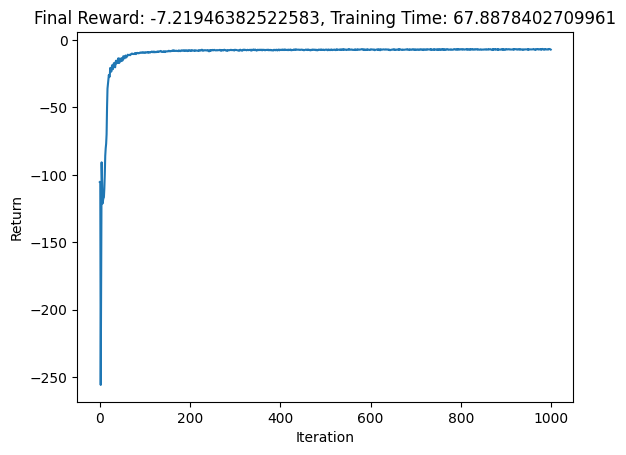

In [10]:
rewards = -res_dict["metrics"]
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [11]:
new_train_state = res_dict["runner_state"].train_state

def policy_trained(obs, key):
    return train_state.apply_fn(new_train_state.params, obs)

In [12]:
env_eval = HoveringStateEnv(
    max_steps_in_episode=6 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.05,
    yaw_scale=0.05,
    pitch_roll_scale=0.05,
    omega_std=0.05,
    drone_path=drone_path,
)
env_eval = MinMaxObservationWrapper(env_eval)
transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))

239


/home/yanrui/tempstorage4/rpg_flightning/flightning/envs/hovering_state_env.py:440: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


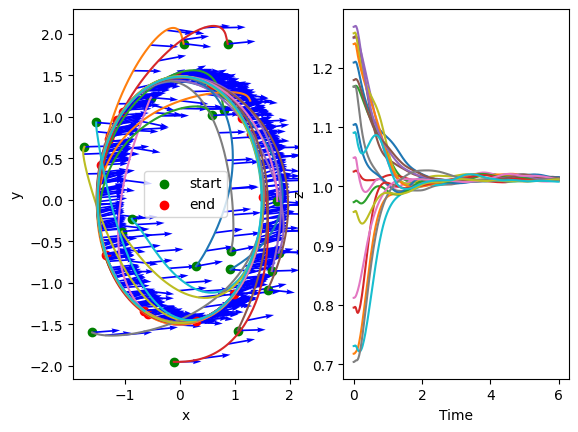

In [13]:
env_eval.plot_trajectories(transitions_eval)

In [14]:
transitions_eval.state.quadrotor_state.R[1][-1,:]

Array([[ 0.9749677 , -0.16388354,  0.15025555],
       [ 0.19728267,  0.94931334, -0.24470277],
       [-0.10253897,  0.2682208 ,  0.9578875 ]], dtype=float32)

In [15]:
transitions_eval.state.quadrotor_state.time_elapsed[1][-1]

AttributeError: 'QuadrotorState' object has no attribute 'time_elapsed'

In [16]:
from orbax.checkpoint import PyTreeCheckpointer
path = FLIGHTNING_PATH + "/../examples/saved_params"
ckptr = PyTreeCheckpointer()
ckptr.save(path, new_train_state.params)

In [ ]:
train_state.apply_fn(new_train_state.params, transitions_eval.obs[10][-14])